#1. Natural Language Processing (NLP) Task

##1.1 Development Environment and Data Acquisition


###1.1.1 Mount Google Drive and File Access

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted")

Mounted at /content/drive
Drive mounted


###1.1.2 Library Dependencies

In [ ]:
# Standard Libraries
import pandas as pd
import numpy as np
import re
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Natural Language Processing
import nltk
from nltk.stem import WordNetLemmatizer


# Machine Learning & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout


# Setup
nltk.download('wordnet')
from google.colab import drive
drive.mount('/content/drive')
print("Libraries imported")

[nltk_data] Downloading package wordnet to /root/nltk_data...


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported


1.1.3 Dataset Loading and Initial Data Inspection

In [ ]:
file_path = "/content/drive/MyDrive/True vs Fake Dataset/10.True vs. Fake News Dataset-20260503T080531Z-3-001/10.True vs. Fake News Dataset/truevsfakenews.csv"
df = pd.read_csv(file_path)
print("Rows:", len(df))
print("Columns:", list(df.columns))
print("First row:")
print(df.head(1))

Rows: 20000
Columns: ['text', 'label']
First row:
                                                text label
0  WASHINGTON (Reuters) - The Republican and Demo...  true


##1.2 Exploratory Data Analysis (EDA)

Unique values in label column: ['true' 'fake']


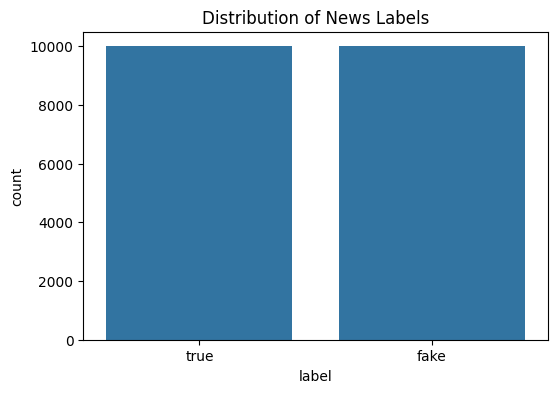

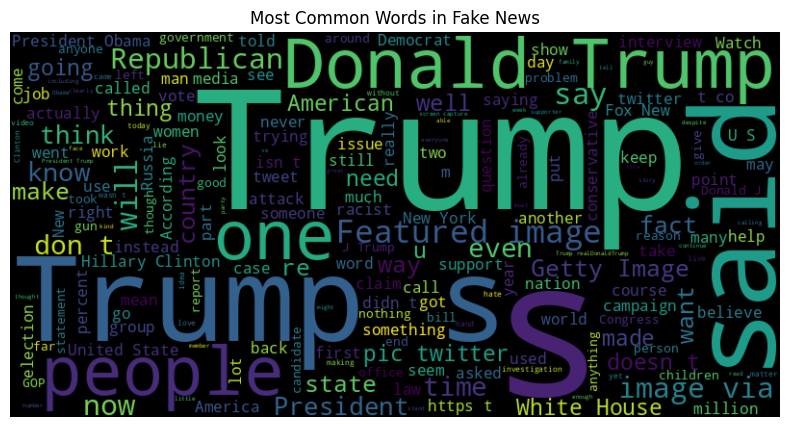

In [ ]:
# DATA QUALITY CHECK
unique_labels = df['label'].unique()
print(f"Unique values in label column: {unique_labels}")

#1. Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Distribution of News Labels')
plt.show()

#2. Word Cloud
# We filter by checking if the label is 'Fake' (case-insensitive) or 0
fake_condition = df['label'].astype(str).str.lower().str.contains('fake|0')
fake_text = " ".join(df[fake_condition]['text'].astype(str))

if len(fake_text) > 10:
    wordcloud_fake = WordCloud(width=800, height=400, background_color='black').generate(fake_text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud_fake, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Common Words in Fake News')
    plt.show()
else:
    print("Error: Could not find any text for 'Fake' news. Check the 'Unique values' printed above.")

##1.3 Text Preprocessing and Data Preparation for Deep Learning

In [ ]:
# 1. Cleaning Function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r"\\W"," ",text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

# Apply cleaning
print("Cleaning text...")
df['clean_text'] = df['text'].apply(clean_text)

# 2. Convert Labels to Numbers (Mapping 'fake' to 0 and 'true' to 1)
df['label'] = df['label'].astype(str).str.lower().str.strip().map({'fake': 0, 'true': 1})

# 3. Split Data
X = df['clean_text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Tokenization and Padding
max_words = 10000
max_len = 300

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

print("Text data prepared!")
print(f"Sample sequence: {X_train_seq[0][:10]}...") # Shows first 10 numbers of a sentence

Cleaning text...
Text data prepared!
Sample sequence: [  26  456   25 2172 1839  475 3343 2725 2718 5314]...


# 2. Neural Network Architecture and Training

## 2.1 Sequential Model Implementation

###### 2.1.1 Model 1: Simple Recurrent Neural Network (RNN)


In [ ]:
#MODEL 1: Simple RNN
vocab_size = 10000 # Must match max_words from previous step
embedding_dim = 128
max_len = 300

model_rnn = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    SimpleRNN(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification (Fake vs True)
])

model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Simple RNN Model Summary:")
model_rnn.summary()

# Training
print("\nStarting Training (RNN)...")
history_rnn = model_rnn.fit(
    X_train_seq, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_seq, y_test)
)

Simple RNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting Training (RNN)...
Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 148ms/step - accuracy: 0.9452 - loss: 0.1538 - val_accuracy: 0.9872 - val_loss: 0.0440
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 143ms/step - accuracy: 0.9924 - loss: 0.0317 - val_accuracy: 0.9855 - val_loss: 0.0566
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.9889 - loss: 0.0373 - val_accuracy: 0.9900 - val_loss: 0.0378
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 151ms/step - accuracy: 0.9907 - loss: 0.0311 - val_accuracy: 0.9920 - val_loss: 0.0347
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 147ms/step - accuracy: 0.9944 - loss: 0.0184 - val_accuracy: 0.9895 - val_loss: 0.0531


### 2.1.2 Model 2: Long Short-Term Memory (LSTM)

In [ ]:
model_lstm = Sequential([
    Embedding(vocab_size, embedding_dim),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("LSTM Model Summary:")
model_lstm.summary()

# Training
print("\nStarting Training (LSTM)...")
history_lstm = model_lstm.fit(
    X_train_seq, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_seq, y_test)
)

LSTM Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting Training (LSTM)...
Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 430ms/step - accuracy: 0.9644 - loss: 0.1363 - val_accuracy: 0.9860 - val_loss: 0.0560
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 430ms/step - accuracy: 0.9894 - loss: 0.0352 - val_accuracy: 0.9937 - val_loss: 0.0262
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 443ms/step - accuracy: 0.9921 - loss: 0.0262 - val_accuracy: 0.9918 - val_loss: 0.0466
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 119s 475ms/step - accuracy: 0.9972 - loss: 0.0102 - val_accuracy: 0.9930 - val_loss: 0.0320
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 441ms/step - accuracy: 0.9996 - loss: 0.0037 - val_accuracy: 0.9925 - val_loss: 0.0260


## 2.2 Embedding Layer Optimization

### 2.2.1 Training Custom Word2Vec and Word2Vec+LSTM Model

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.7 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

# 1. Prepare sentences for Word2Vec
sentences = [text.split() for text in X_train]

# 2. Train Word2Vec model
print("Training Word2Vec model...")
w2v_model = Word2Vec(sentences, vector_size=128, window=5, min_count=1, workers=4)

# 3. Create Embedding Matrix
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, 128))

for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

# 4. Build Model with Pre-trained Weights
model_w2v = Sequential([
    Embedding(vocab_size, 128, weights=[embedding_matrix], trainable=False),
    LSTM(64),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_w2v.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nWord2Vec + LSTM Training...")
history_w2v = model_w2v.fit(X_train_seq, y_train, epochs=5, batch_size=64, validation_data=(X_test_seq, y_test))

Training Word2Vec model...

Word2Vec + LSTM Training...
Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 85s 328ms/step - accuracy: 0.9675 - loss: 0.1065 - val_accuracy: 0.9893 - val_loss: 0.0364
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 319ms/step - accuracy: 0.9891 - loss: 0.0391 - val_accuracy: 0.9948 - val_loss: 0.0207
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 319ms/step - accuracy: 0.9907 - loss: 0.0325 - val_accuracy: 0.9858 - val_loss: 0.0388
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 86s 334ms/step - accuracy: 0.9942 - loss: 0.0196 - val_accuracy: 0.9937 - val_loss: 0.0199
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 322ms/step - accuracy: 0.9951 - loss: 0.0189 - val_accuracy: 0.9925 - val_loss: 0.0224


# 3. Model Evaluation and Performance Metrics

125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step
Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      2055
        True       0.99      1.00      0.99      1945

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



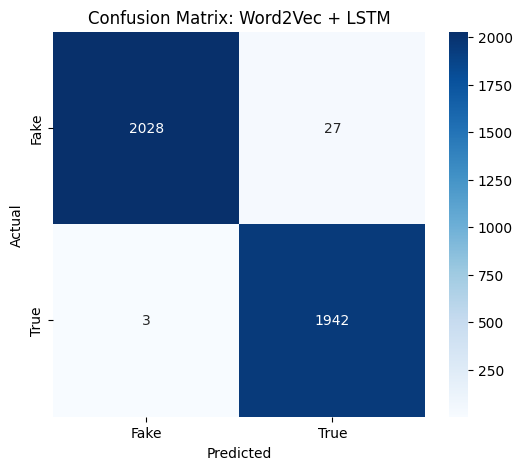

In [ ]:
# 1. Get predictions
y_pred = (model_w2v.predict(X_test_seq) > 0.5).astype("int32")

# 2. Print Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Word2Vec + LSTM')
plt.show()

## 3.1 Testing with our own news

In [ ]:
def predict_news(news_sentence):
    # Preprocess the input
    cleaned = clean_text(news_sentence)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=300)

    # Predict
    prediction = model_w2v.predict(padded)[0][0]

    label = "TRUE" if prediction > 0.5 else "FAKE"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(f"News: {news_sentence}")
    print(f"Prediction: {label} ({confidence*100:.2f}% confidence)")
    print("-" * 30)

# Test it out!
predict_news("The president just signed a new law regarding space travel to Mars.")
predict_news("Breaking: Secret aliens found living in the basement of the White House!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
News: The president just signed a new law regarding space travel to Mars.
Prediction: TRUE (99.78% confidence)
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
News: Breaking: Secret aliens found living in the basement of the White House!
Prediction: TRUE (98.87% confidence)
------------------------------


# 4. Deployment and Real-time Inference

## 4.1NLP Task: Real-time Graphical Interface

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

def interface_predict(news_text):
    # 1. Preprocess the input
    cleaned = clean_text(news_text)

    # 2. Tokenize and Pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=300)

    # 3. Predict using the trained model
    prediction = model_w2v.predict(padded)[0][0]

    # 4. Logic for label and confidence
    if prediction > 0.5:
        label = "TRUE NEWS"
        confidence = prediction
    else:
        label = "FAKE NEWS"
        confidence = 1 - prediction

    return f"Status: {label}\nConfidence Score: {confidence*100:.2f}%"

# Launching the interface
app = gr.Interface(
    fn=interface_predict,
    inputs=gr.Textbox(lines=5, label="Paste News Article Here"),
    outputs=gr.Textbox(label="Result"),
    title="Fake News Detection System",
    description="Analyze news articles using a high-accuracy Word2Vec + LSTM model."
)
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://899b11717bcac6570c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Evaluation: Comparison and Visualization

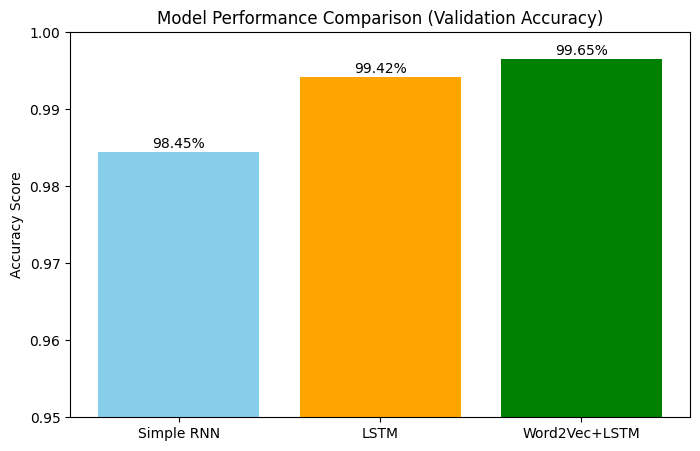

In [ ]:
import matplotlib.pyplot as plt

models = ['Simple RNN', 'LSTM', 'Word2Vec+LSTM']
accuracies = [0.9845, 0.9942, 0.9965]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'orange', 'green'])
plt.title('Model Performance Comparison (Validation Accuracy)')
plt.ylabel('Accuracy Score')
plt.ylim(0.95, 1.0) # Zoomed in to show the small differences between high scores
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.0005, f"{v*100:.2f}%", ha='center')
plt.show()